Case study 
group # 1

In [15]:
# install all the depensencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [16]:
#load the data
file_path = r"C:\Users\akbar\Documents\MAYERFIELD\UKDA-6970-stata\BSE_2010.dta"

# Keep numeric codes: some Stata labels are duplicated.
data = pd.read_stata(file_path, convert_categoricals=False)

df_main = pd.DataFrame(data)

df_main.head(10)

,Unqid,Country,zgor,zq88,zq89,zq90,zq91_1,zq91_2,zq101,eq1,...,CitizenadjBA,CitizenadjIn,CitizenadjPa,CitizenadjBang,Citizenadjtotal,Popdensity,Intno,Inteth,Intsex,PSUIdentifier
0,100011,1,7,1,31,1,9,4.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
1,100013,1,3,2,49,6,1,NaN,3,NaN,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
2,100014,1,3,2,33,1,4,2.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
3,100015,1,3,2,37,1,2,0.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
4,100020,1,7,1,45,1,6,2.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
5,100035,1,7,1,62,1,2,0.0,8,11.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
6,100037,1,4,2,27,6,4,1.0,8,NaN,...,17.27,21.33,68.88,20.60,165.53,4558.823529,70619,5,2,1443
7,100038,1,7,2,28,1,6,4.0,8,10.0,...,171.13,32.39,108.36,22.66,588.13,7715.789474,71417,6,2,1197
8,100046,1,7,2,51,6,1,NaN,11,NaN,...,259.05,10.27,0.00,8.24,593.21,7269.565217,69192,7,2,1103
9,100049,1,5,2,44,1,5,3.0,12,14.0,...,17.27,9.48,7.56,0.00,99.58,6151.851852,71570,7,2,1362


In [17]:

df_main.columns
columns = [
    "Unqid",
    "zqinc",
    "bq9_1",
    "bq9_2",
    "bq9_3",
    "ScreenEthQairre",
    "Weight_trimmedF2FALL5",
    "PSUIdentifier",
    "FinalStratum",
]

df_study = df_main[columns].copy()

display(df_study.head())
print(df_study.shape)

,Unqid,zqinc,bq9_1,bq9_2,bq9_3,ScreenEthQairre,Weight_trimmedF2FALL5,PSUIdentifier,FinalStratum
0,100011,13,2,NaN,NaN,4,1.603379,1148,90
1,100013,4,2,NaN,NaN,1,0.320863,1149,33
2,100014,4,1,2.0,NaN,4,0.738677,1149,33
3,100015,4,2,NaN,NaN,4,0.906278,1149,33
4,100020,3,2,NaN,NaN,4,2.382369,1148,90


(2787, 9)


In [18]:
# Readable names for the study columns; keep df_main unchanged.
column_names = {
    'zq91_1': 'N_in_household',
    'bq9_1': 'Party_identification',
    'zqinc': 'Household_income',
    'ScreenEthQairre':'Ethnic_group',
    'Weight_trimmedF2FALL5': 'Survey_weight'
}


In [19]:
# Keep numeric codes separately for analysis and repeatable labeling.
df_study_codes = df_main[
    ['Unqid', 'zq91_1', 'bq9_1', 'zqinc', 'ScreenEthQairre', 'Weight_trimmedF2FALL5']
].rename(columns=column_names).copy()

df_study = df_study_codes.copy()
display(df_study.head())


,Unqid,N_in_household,Party_identification,Household_income,Ethnic_group,Survey_weight
0,100011,9,2,13,4,1.603379
1,100013,1,2,4,1,0.320863
2,100014,4,1,4,4,0.738677
3,100015,2,2,4,4,0.906278
4,100020,6,2,3,4,2.382369


In [20]:
# Convert response codes to readable labels, starting from numeric data each time.
df_study = df_study_codes.copy() 
zqinc_labels = {
    -2: "Refused",
    -1: "Don't Know",
     1: "0 - 5000",
     2: "5001 - 10000",
     3: "10001 - 15000",
     4: "15001 - 20000",
     5: "20001 - 25000",
     6: "25001 - 30000",
     7: "30001 - 35000",
     8: "35001 - 40000",
     9: "41000 - 45000",
    10: "45001 - 50000",
    11: "50001 - 60000",
    12: "60001 - 70000",
    13: "70001 - 80000",
    14: "80001 or more",
    17: "Not Stated"

}

df_study['Household_income'] = df_study['Household_income'].map(zqinc_labels)

bq9_1_labels = {
    -2: "Refused",
    -1: "Don't Know",
     1: "None/No",
     2: "Labour",
     3: "Conservatives",
     4: "Liberal Democrats",
     5: "Scottish National Party (SNP)",
     6: "Plaid Cymru",
     7: "Green Party",
     8: "United Kingdom Independence Party (UKIP)",
     9: "British National Party (BNP)",
    10: "Coalition party/Conservative-Lib dem party",
    11: "Other",
    12: "Respect",
    15: "Not Stated"
}

df_study['Party_identification'] = df_study['Party_identification'].map(bq9_1_labels)

ScreenEthQairre_labels = {
    1: "Black Caribbean",
    2: "Black African",
    3: "Indian",
    4: "Pakistani",
    5: "Bangladeshi",
}

df_study['Ethnic_group'] = df_study['Ethnic_group'].map(ScreenEthQairre_labels)

# Check that every observed code has a label.
for column in ['Household_income', 'Party_identification', 'Ethnic_group']:
    unmapped = df_study_codes[column].notna() & df_study[column].isna()
    assert not unmapped.any(), f"Unmapped codes in {column}"

display(df_study.head(10))

,Unqid,N_in_household,Party_identification,Household_income,Ethnic_group,Survey_weight
0,100011,9,Labour,70001 - 80000,Pakistani,1.603379
1,100013,1,Labour,15001 - 20000,Black Caribbean,0.320863
2,100014,4,None/No,15001 - 20000,Pakistani,0.738677
3,100015,2,Labour,15001 - 20000,Pakistani,0.906278
4,100020,6,Labour,10001 - 15000,Pakistani,2.382369
5,100035,2,Conservatives,30001 - 35000,Pakistani,0.976432
6,100037,4,Labour,15001 - 20000,Pakistani,2.001654
7,100038,6,Labour,Refused,Pakistani,0.545314
8,100046,1,Labour,Refused,Black Caribbean,0.301202
9,100049,5,None/No,30001 - 35000,Black African,0.702906


In [21]:
# Export AFTER applying labels. UTF-8 with BOM also opens well in Excel.
from pathlib import Path

csv_path = Path(file_path).parent.parent / 'df_study.csv'
df_study.to_csv(csv_path, index=False, encoding='utf-8-sig')

# Read the saved CSV back to verify its labels.
study_csv = pd.read_csv(csv_path)
assert study_csv['Household_income'].equals(df_study['Household_income'])
assert study_csv['Party_identification'].equals(df_study['Party_identification'])
print(f"Saved {len(study_csv):,} rows to: {csv_path}")
display(study_csv.head(10))


Saved 2,787 rows to: C:\Users\akbar\Documents\MAYERFIELD\df_study.csv


,Unqid,N_in_household,Party_identification,Household_income,Ethnic_group,Survey_weight
0,100011,9,Labour,70001 - 80000,Pakistani,1.603379
1,100013,1,Labour,15001 - 20000,Black Caribbean,0.320863
2,100014,4,None/No,15001 - 20000,Pakistani,0.738677
3,100015,2,Labour,15001 - 20000,Pakistani,0.906278
4,100020,6,Labour,10001 - 15000,Pakistani,2.382369
5,100035,2,Conservatives,30001 - 35000,Pakistani,0.976432
6,100037,4,Labour,15001 - 20000,Pakistani,2.001654
7,100038,6,Labour,Refused,Pakistani,0.545314
8,100046,1,Labour,Refused,Black Caribbean,0.301202
9,100049,5,None/No,30001 - 35000,Black African,0.702906


In [22]:
# countiung the refused and unknowns
count_refused = df_study['Household_income'].eq('Refused').sum()
count_unknown = df_study['Household_income'].eq("Don't Know").sum()
count_refused_1 = df_study['Party_identification'].eq('Refused').sum()
count_unknown_1 = df_study['Party_identification'].eq("Don't Know").sum()

print(f"Count of 'Refused' in Household_income: {count_refused}")
print(f"Count of 'Don't Know' in Household_income: {count_unknown}")
print(f"Count of 'Refused' in Party_identification: {count_refused_1}")
print(f"Count of 'Don't Know' in Party_identification: {count_unknown_1}")

Count of 'Refused' in Household_income: 602
Count of 'Don't Know' in Household_income: 453
Count of 'Refused' in Party_identification: 52
Count of 'Don't Know' in Party_identification: 197


In [23]:
# Creates a separate dataset; does not change df_study.
analysis = df_main[
    ["zqinc", "bq9_1", "ScreenEthQairre", "Weight_trimmedF2FALL5"]
].copy()

analysis.columns = ["Income", "Party", "Ethnicity", "Weight"]

ethnicity_labels = {
    1: "Black Caribbean", 2: "Black African", 3: "Indian",
    4: "Pakistani", 5: "Bangladeshi"
}

party_labels = {
    1: "None/No", 2: "Labour", 3: "Conservative",
    4: "Liberal Democrat",
    **{code: "Other parties" for code in range(5, 13)}
}

analysis["Ethnicity"] = analysis["Ethnicity"].map(ethnicity_labels)
analysis["Party"] = analysis["Party"].map(party_labels)

# Refused, Don't Know, Not Stated and actual blanks count as missing.
analysis["Income_missing"] = ~analysis["Income"].isin(range(1, 15))


# 1. INVESTIGATE MISSING INCOME
# These percentages describe actual respondents (unweighted).
def missing_summary(data, group):
    summary = data.groupby(group, observed=True)["Income_missing"].agg(
        Respondents="size",
        Missing_income="sum",
        Missing_percent="mean"
    )
    summary["Missing_percent"] = (summary["Missing_percent"] * 100).round(1)
    return summary


print("Missing income by ethnicity:")
display(missing_summary(analysis, "Ethnicity"))

# Unknown/refused party responses are excluded from this table.
# None/No is retained as a valid response.
print("Missing income by known party identification:")
display(missing_summary(analysis, "Party"))


# 2. SELECT VALID INCOME AND PARTY RESPONSES
complete = analysis.loc[
    ~analysis["Income_missing"] & analysis["Party"].notna()
].copy()

print(f"Original respondents: {len(analysis):,}")
print(f"Valid income and party responses: {len(complete):,}")
print(f"Excluded: {len(analysis) - len(complete):,}")

assert complete["Weight"].notna().all()
assert (complete["Weight"] > 0).all()


# 3. MAIN GROUPING AND SENSITIVITY CHECK
def compare_groups(data, bins, labels, name):
    data = data.copy()
    data["Income_group"] = pd.cut(
        data["Income"], bins=bins, labels=labels
    )

    # Weighted percentages for describing party identification.
    weighted = pd.crosstab(
        data["Income_group"],
        data["Party"],
        values=data["Weight"],
        aggfunc="sum",
        dropna=False
    ).fillna(0)

    percentages = weighted.div(weighted.sum(axis=1), axis=0) * 100

    print(f"\n{name}: weighted party percentages")
    display(percentages.round(1))

    # Ordinary chi-square uses UNWEIGHTED respondent counts.
    # Exploratory only: this test does not account for the survey design.
    counts = pd.crosstab(data["Income_group"], data["Party"])
    counts = counts.loc[counts.sum(axis=1) > 0, counts.sum(axis=0) > 0]

    chi2, p, dof, expected = chi2_contingency(counts, correction=False)

    # Unweighted descriptive effect size.
    n = counts.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * min(np.array(counts.shape) - 1)))

    return {
        "Grouping": name,
        "N": n,
        "Chi_square_unweighted": chi2,
        "Degrees_of_freedom": dof,
        "P_value_exploratory": p,
        "Cramers_V_unweighted": cramers_v,
        "Minimum_expected_count": expected.min(),
        "Expected_cells_below_5_percent": (expected < 5).mean() * 100
    }


results = [
    compare_groups(
        complete,
        bins=[0, 2, 4, 8, 14],
        labels=["Up to £10,000", "£10,001–20,000",
                "£20,001–40,000", "Above £40,000"],
        name="4 income groups"
    ),
    compare_groups(
        complete,
        bins=[0, 4, 8, 14],
        labels=["Up to £20,000", "£20,001–40,000", "Above £40,000"],
        name="3 income groups"
    )
]

print("\nSensitivity comparison:")
display(pd.DataFrame(results).set_index("Grouping").round(4))

# Compare patterns, Cramer's V and p-values across the two groupings.
# Small expected counts can make the chi-square approximation unreliable.
# These p-values are exploratory, NOT the final survey-adjusted results.
# Final inference must also account for PSUIdentifier, FinalStratum and weights.
# This comparison does not resolve potential bias from missing income.

Missing income by ethnicity:


,Respondents,Missing_income,Missing_percent
Ethnicity,,,
Bangladeshi,274,119,43.4
Black African,579,187,32.3
Black Caribbean,668,215,32.2
Indian,593,203,34.2
Pakistani,673,331,49.2


Missing income by known party identification:


,Respondents,Missing_income,Missing_percent
Party,,,
Conservative,232,79,34.1
Labour,1661,595,35.8
Liberal Democrat,253,94,37.2
None/No,342,152,44.4
Other parties,50,21,42.0


Original respondents: 2,787
Valid income and party responses: 1,597
Excluded: 1,190

4 income groups: weighted party percentages


Party,Conservative,Labour,Liberal Democrat,None/No,Other parties
Income_group,,,,,
"Up to £10,000",8.4,69.3,11.2,9.3,1.7
"£10,001–20,000",6.4,71.3,9.3,10.9,2.1
"£20,001–40,000",14.6,63.3,10.8,10.1,1.2
"Above £40,000",16.9,61.2,10.5,10.8,0.6



3 income groups: weighted party percentages


Party,Conservative,Labour,Liberal Democrat,None/No,Other parties
Income_group,,,,,
"Up to £20,000",7.4,70.4,10.2,10.2,1.9
"£20,001–40,000",14.6,63.3,10.8,10.1,1.2
"Above £40,000",16.9,61.2,10.5,10.8,0.6



Sensitivity comparison:


,N,Chi_square_unweighted,Degrees_of_freedom,P_value_exploratory,Cramers_V_unweighted,Minimum_expected_count,Expected_cells_below_5_percent
Grouping,,,,,,,
4 income groups,1597,26.4255,12,0.0093,0.0743,5.2116,0.0
3 income groups,1597,26.1927,8,0.0010,0.0906,5.2116,0.0


### Missing income across groups
These charts show who may be underrepresented after incomplete responses are excluded. Percentages use the total within each group.

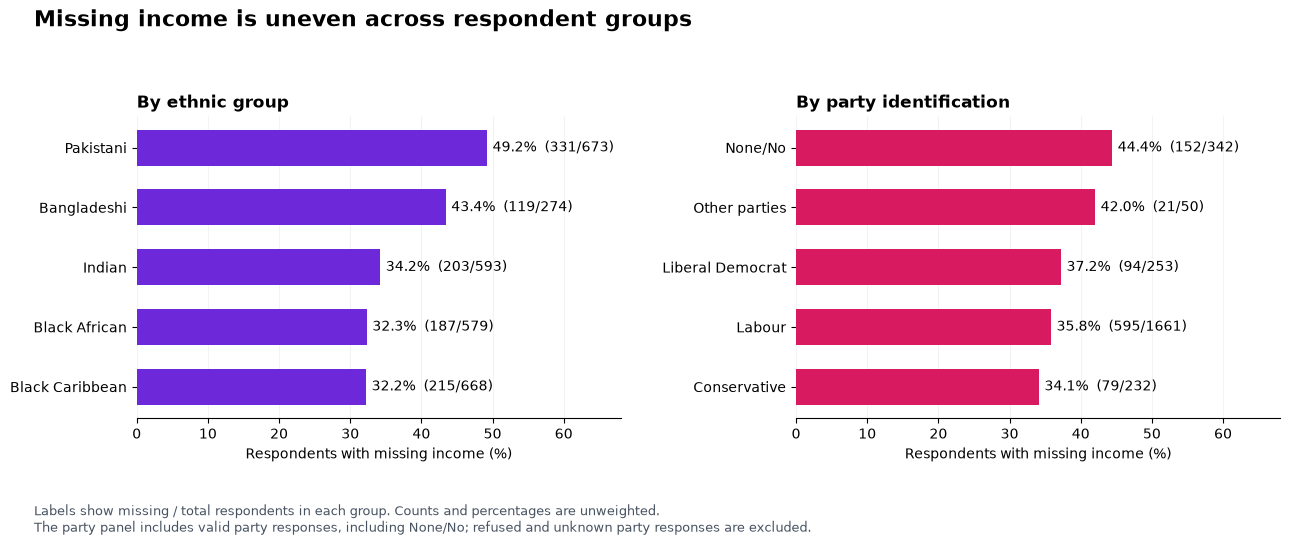

In [24]:
# Compare missing income within each group (unweighted respondents).
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, group, title in zip(
    axes, ['Ethnicity', 'Party'], ['By ethnic group', 'By party identification']
):
    chart_data = missing_summary(analysis, group).sort_values('Missing_percent')
    ax.barh(chart_data.index, chart_data['Missing_percent'], color=('#6D28D9' if group == 'Ethnicity' else '#D81B60'), height=0.6)
    for i, row in enumerate(chart_data.itertuples()):
        ax.text(row.Missing_percent + 0.8, i,
                f'{row.Missing_percent:.1f}%  ({row.Missing_income}/{row.Respondents})',
                va='center', fontsize=10)
    ax.set_xlim(0, 68)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_xlabel('Respondents with missing income (%)')
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)

fig.suptitle('Missing income is uneven across respondent groups',
             x=0.03, ha='left', fontsize=16, fontweight='bold')
fig.text(0.03, 0.03,
         'Labels show missing / total respondents in each group. Counts and percentages are unweighted.\n'
         'The party panel includes valid party responses, including None/No; refused and unknown party responses are excluded.',
         fontsize=9, color='#485362')
fig.tight_layout(rect=[0, 0.13, 1, 0.92], w_pad=3)
plt.show()


### Respondents retained for analysis
A valid income response and a valid party-identification response are required. None/No remains a valid party response.

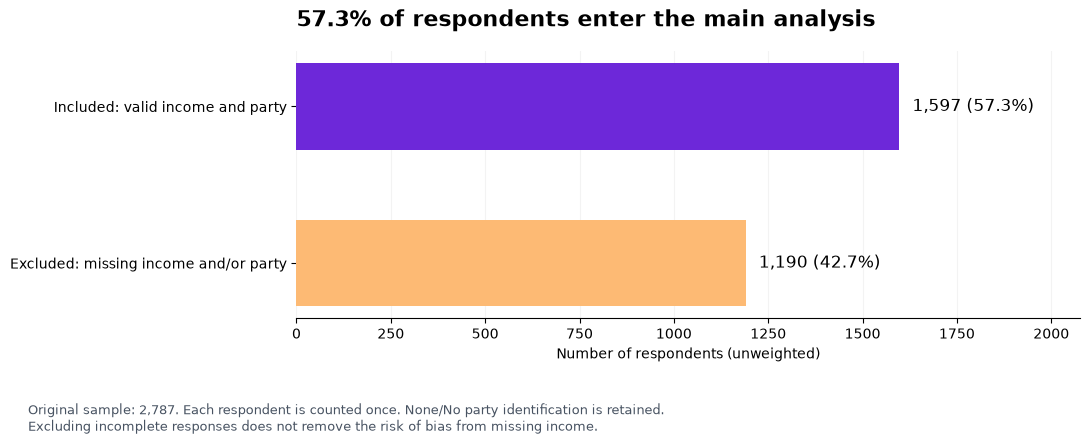

In [25]:
# Show the sample available for the income–party analysis.
sample_counts = [len(complete), len(analysis) - len(complete)]
sample_labels = ['Included: valid income and party', 'Excluded: missing income and/or party']

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(sample_labels, sample_counts, color=['#6D28D9', '#FDBA74'], height=0.55)
ax.invert_yaxis()
for i, count in enumerate(sample_counts):
    ax.text(count + 35, i, f'{count:,} ({count / len(analysis):.1%})',
            va='center', fontsize=12)
ax.set_xlim(0, max(sample_counts) * 1.3)
ax.set_xlabel('Number of respondents (unweighted)')
ax.set_title(f'{len(complete) / len(analysis):.1%} of respondents enter the main analysis',
             loc='left', fontsize=16, fontweight='bold', pad=18)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.15)
ax.set_axisbelow(True)
fig.text(0.03, 0.03,
         f'Original sample: {len(analysis):,}. Each respondent is counted once. None/No party identification is retained.\n'
         'Excluding incomplete responses does not remove the risk of bias from missing income.',
         fontsize=9, color='#485362')
fig.tight_layout(rect=[0, 0.15, 1, 1])
plt.show()


### Chi-square sensitivity results
The table compares the existing exploratory tests. The adjacent chart shows association strength on the full 0–1 scale. These are **unweighted tests**, unlike the weighted party-percentage chart below.

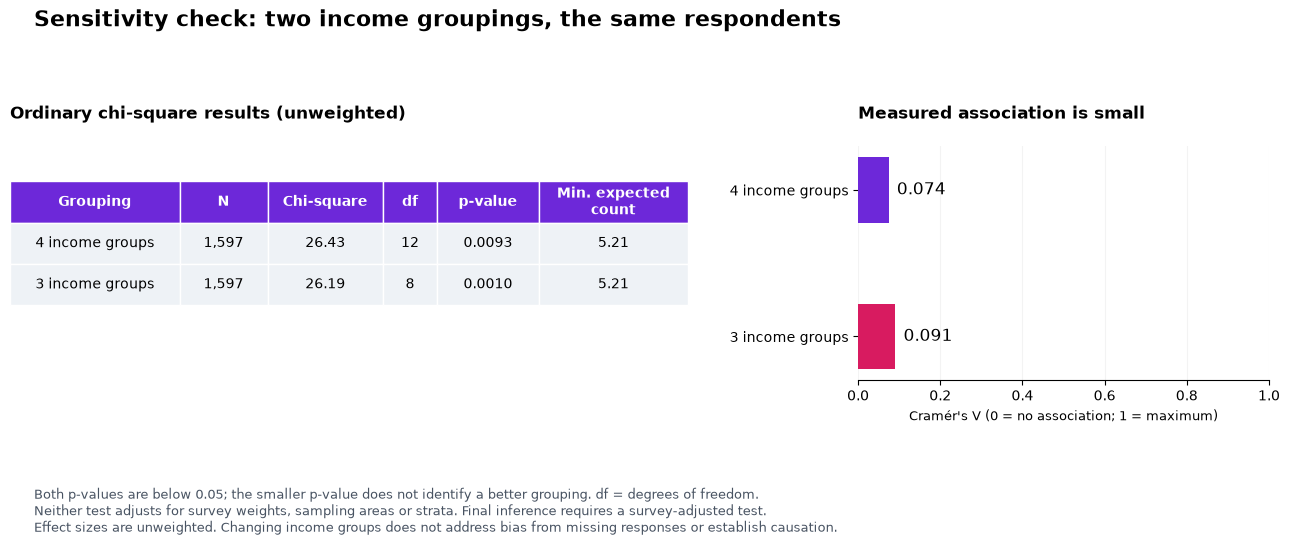

In [26]:
# Present the existing test results alongside their effect sizes.
# These ordinary chi-square tests are exploratory and are NOT survey-adjusted.
test_results = pd.DataFrame(results).set_index('Grouping')
fig, (ax_table, ax_effect) = plt.subplots(
    1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.65, 1]}
)

table_rows = []
for group, row in test_results.iterrows():
    table_rows.append([
        group, f"{int(row['N']):,}", f"{row['Chi_square_unweighted']:.2f}",
        str(int(row['Degrees_of_freedom'])),
        f"{row['P_value_exploratory']:.4f}",
        f"{row['Minimum_expected_count']:.2f}"
    ])

ax_table.axis('off')
ax_table.set_title('Ordinary chi-square results (unweighted)',
                   loc='left', fontsize=12, fontweight='bold', pad=20)
table = ax_table.table(
    cellText=table_rows,
    colLabels=['Grouping', 'N', 'Chi-square', 'df', 'p-value', 'Min. expected\ncount'],
    colWidths=[0.25, 0.13, 0.17, 0.08, 0.15, 0.22],
    cellLoc='center', bbox=[0, 0.32, 1, 0.53]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('white')
    cell.set_facecolor('#6D28D9' if row == 0 else '#eef2f6')
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')

effect_sizes = test_results['Cramers_V_unweighted']
ax_effect.barh(effect_sizes.index, effect_sizes, color=['#6D28D9', '#D81B60'], height=0.45)
ax_effect.invert_yaxis()
for i, value in enumerate(effect_sizes):
    ax_effect.text(value + 0.02, i, f'{value:.3f}', va='center', fontsize=12)
ax_effect.set_xlim(0, 1)
ax_effect.set_xlabel("Cramér's V (0 = no association; 1 = maximum)", fontsize=9)
ax_effect.set_title('Measured association is small',
                    loc='left', fontsize=12, fontweight='bold', pad=20)
ax_effect.spines[['top', 'right', 'left']].set_visible(False)
ax_effect.grid(axis='x', alpha=0.15)
ax_effect.set_axisbelow(True)

fig.suptitle('Sensitivity check: two income groupings, the same respondents',
             x=0.03, ha='left', fontsize=16, fontweight='bold')
fig.text(0.03, 0.03,
         'Both p-values are below 0.05; the smaller p-value does not identify a better grouping. df = degrees of freedom.\n'
         'Neither test adjusts for survey weights, sampling areas or strata. Final inference requires a survey-adjusted test.\n'
         'Effect sizes are unweighted. Changing income groups does not address bias from missing responses or establish causation.',
         fontsize=9, color='#485362')
fig.tight_layout(rect=[0, 0.2, 1, 0.9], w_pad=3)
plt.show()


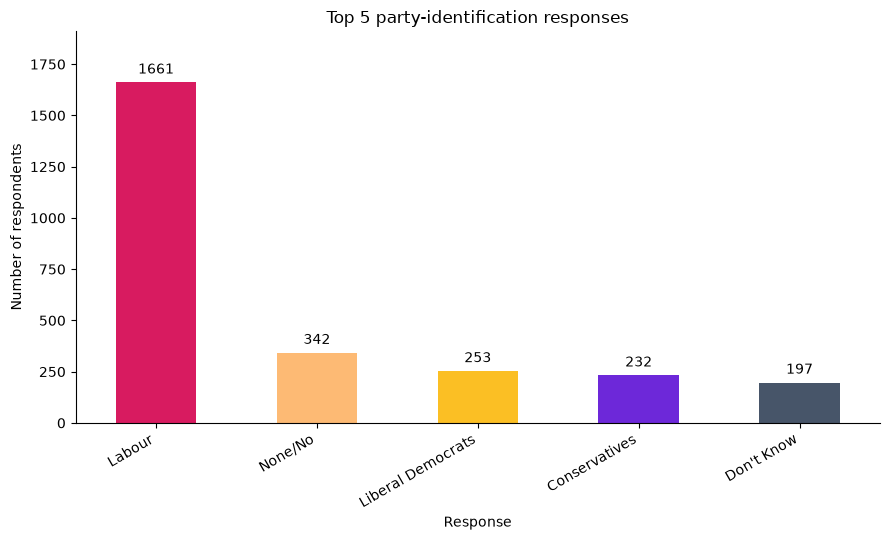

In [27]:
# BIG parties
df_study["Party_identification"].value_counts(dropna=False)

# making chart for the top 5 party-identification responses
top_5 = df_study["Party_identification"].value_counts().head(5)

# Match colours to response names rather than their count ranking.
response_colors = {
    'Labour': '#D81B60', 'Conservatives': '#6D28D9',
    'Liberal Democrats': '#FBBF24', 'None/No': '#FDBA74',
    "Don't Know": '#475569', 'Refused': '#475569'
}
colors = [response_colors.get(response, '#14B8A6') for response in top_5.index]

ax = top_5.plot.bar(figsize=(9, 5.5), color=colors)
ax.bar_label(ax.containers[0], padding=4, fontsize=10)
ax.set_ylim(0, top_5.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)

plt.title("Top 5 party-identification responses")
plt.xlabel("Response")
plt.ylabel("Number of respondents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Party,Labour,Conservative,Liberal Democrat,Other parties,None
Income_group,,,,,
"Up to £10,000",69.3,8.4,11.2,1.7,9.3
"£10,001–20,000",71.3,6.4,9.3,2.1,10.9
"£20,001–40,000",63.3,14.6,10.8,1.2,10.1
"Above £40,000",61.2,16.9,10.5,0.6,10.8


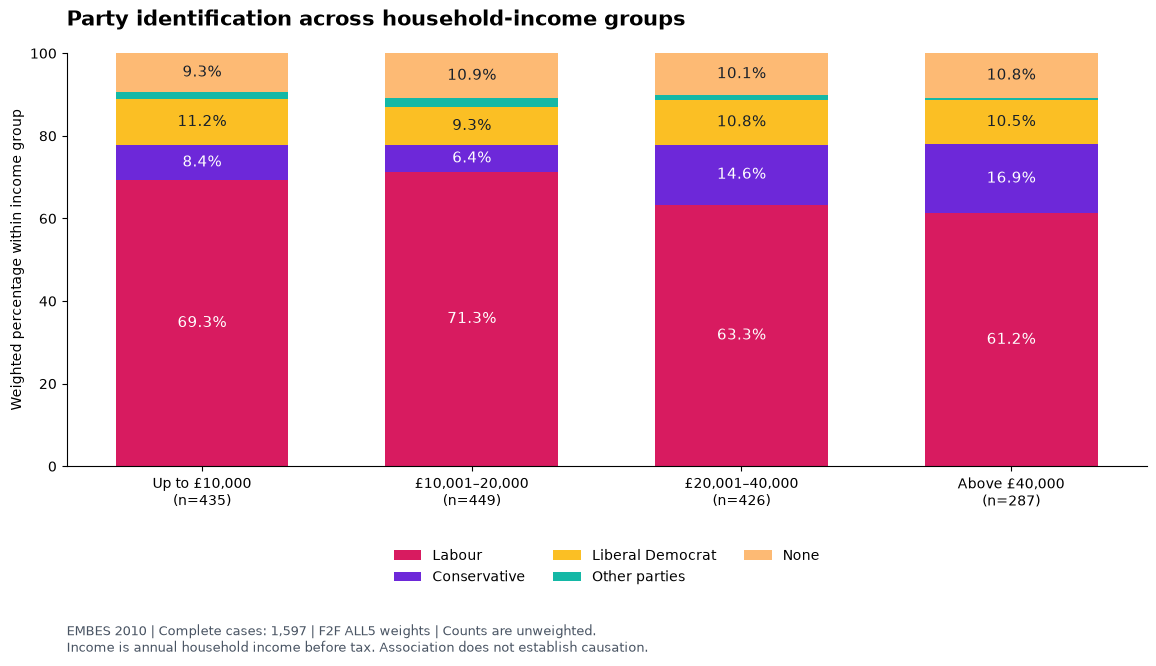

In [28]:
# Making vissualizations

# 1. Select the original numeric variables.
plot_data = df_main[
    ["zqinc", "bq9_1", "Weight_trimmedF2FALL5"]
].copy()

# 2. Keep valid income and party answers.
# Party code 1 (None/No) remains a valid response.
valid = (
    plot_data["zqinc"].between(1, 14)
    & plot_data["bq9_1"].between(1, 12)
)

plot_data = plot_data.loc[valid].copy()

# Check that all included respondents have valid survey weights.
weights = plot_data["Weight_trimmedF2FALL5"]
assert weights.notna().all() and (weights > 0).all()

# 3. Combine the 14 income bands into four groups.
income_labels = [
    "Up to £10,000",
    "£10,001–20,000",
    "£20,001–40,000",
    "Above £40,000",
]

plot_data["Income_group"] = pd.cut(
    plot_data["zqinc"],
    bins=[0, 2, 4, 8, 14],
    labels=income_labels,
)

# 4. Label parties and combine smaller parties.
party_labels = {
    1: "None",
    2: "Labour",
    3: "Conservative",
    4: "Liberal Democrat",
    5: "Other parties",
    6: "Other parties",
    7: "Other parties",
    8: "Other parties",
    9: "Other parties",
    10: "Other parties",
    11: "Other parties",
    12: "Other parties",
}

plot_data["Party"] = plot_data["bq9_1"].map(party_labels)

party_order = [
    "Labour",
    "Conservative",
    "Liberal Democrat",
    "Other parties",
    "None",
]

# 5. Sum survey weights for each income-party combination.
weighted_counts = (
    plot_data.groupby(
        ["Income_group", "Party"], observed=True
    )["Weight_trimmedF2FALL5"]
    .sum()
    .unstack(fill_value=0)
    .reindex(
        index=income_labels,
        columns=party_order,
        fill_value=0,
    )
)

# Convert to percentages WITHIN each income group.
percentages = weighted_counts.div(
    weighted_counts.sum(axis=1), axis=0
) * 100

# Actual respondent counts for the x-axis labels.
sample_sizes = (
    plot_data.groupby("Income_group", observed=True)
    .size()
    .reindex(income_labels, fill_value=0)
)

display(percentages.round(1))

# 6. Draw the stacked percentage chart.
colors = [
    "#D81B60",
    "#6D28D9",
    "#FBBF24",
    "#14B8A6",
    "#FDBA74",
]

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(income_labels))
bottom = np.zeros(len(income_labels))

for party, color in zip(party_order, colors):
    values = percentages[party].to_numpy()

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.64,
        label=party,
        color=color,
    )

    # Label larger segments to avoid overcrowding.
    for i, value in enumerate(values):
        if value >= 6:
            ax.text(
                x[i],
                bottom[i] + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                color=(
                    "white"
                    if party in ["Labour", "Conservative"]
                    else "#17202b"
                ),
            )

    bottom += values

ax.set_xticks(
    x,
    [
        f"{label}\n(n={int(sample_sizes.loc[label])})"
        for label in income_labels
    ],
)

ax.set_ylim(0, 100)
ax.set_ylabel("Weighted percentage within income group")
ax.set_title(
    "Party identification across household-income groups",
    loc="left",
    fontweight="bold",
    fontsize=15,
    pad=20,
)

ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=3,
    frameon=False,
)

fig.text(
    0.08,
    0.025,
    f"EMBES 2010 | Complete cases: {len(plot_data):,} | "
    "F2F ALL5 weights | Counts are unweighted.\n"
    "Income is annual household income before tax. "
    "Association does not establish causation.",
    fontsize=9,
    color="#485362",
)

fig.subplots_adjust(
    left=0.08, right=0.98, top=0.88, bottom=0.29
)

# Optional: uncomment to save the chart.
# fig.savefig("income_party_chart.png", dpi=300, bbox_inches="tight")

plt.show()

### Team contribution: income distributions within Labour and Conservative identifiers
The main stacked chart instead asks which parties respondents identify with **within each income group**.

Here we use survey-weighted percentages, identical axes, and the original 14 income bands.
This makes the unequal party sample sizes comparable without assigning exact incomes or assuming an upper limit for the highest band.
This is a supporting descriptive comparison, not an additional significance test. People are party identifiers, not necessarily voters for that party.


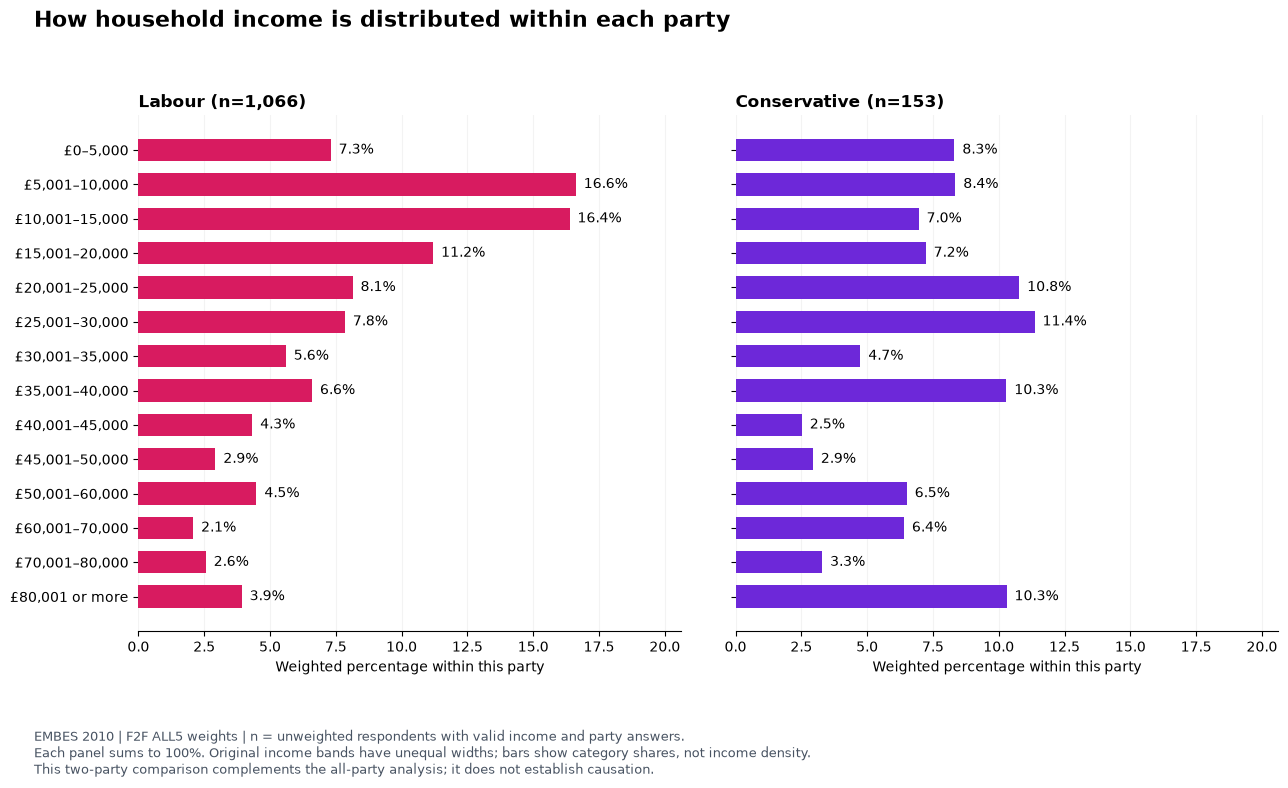

Labour: 48.5% have household income above £20,000 (weighted).
Conservative: 69.1% have household income above £20,000 (weighted).


In [29]:
# Adapted from our teammate's Labour–Conservative distribution chart.
# Each party's bars sum to 100%; only respondents with valid income are included.
comparison_data = complete.loc[
    complete['Party'].isin(['Labour', 'Conservative'])
].copy()

income_band_labels = [
    '£0–5,000', '£5,001–10,000', '£10,001–15,000', '£15,001–20,000',
    '£20,001–25,000', '£25,001–30,000', '£30,001–35,000', '£35,001–40,000',
    '£40,001–45,000', '£45,001–50,000', '£50,001–60,000',
    '£60,001–70,000', '£70,001–80,000', '£80,001 or more'
]
# Band 9 follows the questionnaire (the data label says 41,000–45,000).
income_by_party = pd.crosstab(
    comparison_data['Income'], comparison_data['Party'],
    values=comparison_data['Weight'], aggfunc='sum'
).reindex(range(1, 15)).fillna(0)
income_by_party = income_by_party.div(income_by_party.sum(axis=0), axis=1) * 100
party_sizes = comparison_data['Party'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, party, color in zip(axes, ['Labour', 'Conservative'], ['#D81B60', '#6D28D9']):
    values = income_by_party[party]
    ax.barh(range(14), values, color=color, height=0.65)
    for i, value in enumerate(values):
        ax.text(value + 0.3, i, f'{value:.1f}%', va='center', fontsize=10)
    ax.set_title(f'{party} (n={party_sizes[party]:,})', loc='left', fontweight='bold')
    ax.set_xlabel('Weighted percentage within this party')
    ax.set_xlim(0, income_by_party.to_numpy().max() + 4)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='x', alpha=0.15)
    ax.set_axisbelow(True)
axes[0].set_yticks(range(14), income_band_labels)
axes[0].invert_yaxis()
fig.suptitle('How household income is distributed within each party',
             x=0.03, ha='left', fontsize=16, fontweight='bold')
fig.text(0.03, 0.025,
         'EMBES 2010 | F2F ALL5 weights | n = unweighted respondents with valid income and party answers.\n'
         'Each panel sums to 100%. Original income bands have unequal widths; bars show category shares, not income density.\n'
         'This two-party comparison complements the all-party analysis; it does not establish causation.',
         fontsize=9, color='#485362')
fig.tight_layout(rect=[0, 0.13, 1, 0.94], w_pad=3)
plt.show()

# A short weighted summary to help interpret the distribution chart.
above_20k = income_by_party.loc[5:14].sum()
for party in ['Labour', 'Conservative']:
    print(f'{party}: {above_20k[party]:.1f}% have household income above £20,000 (weighted).')


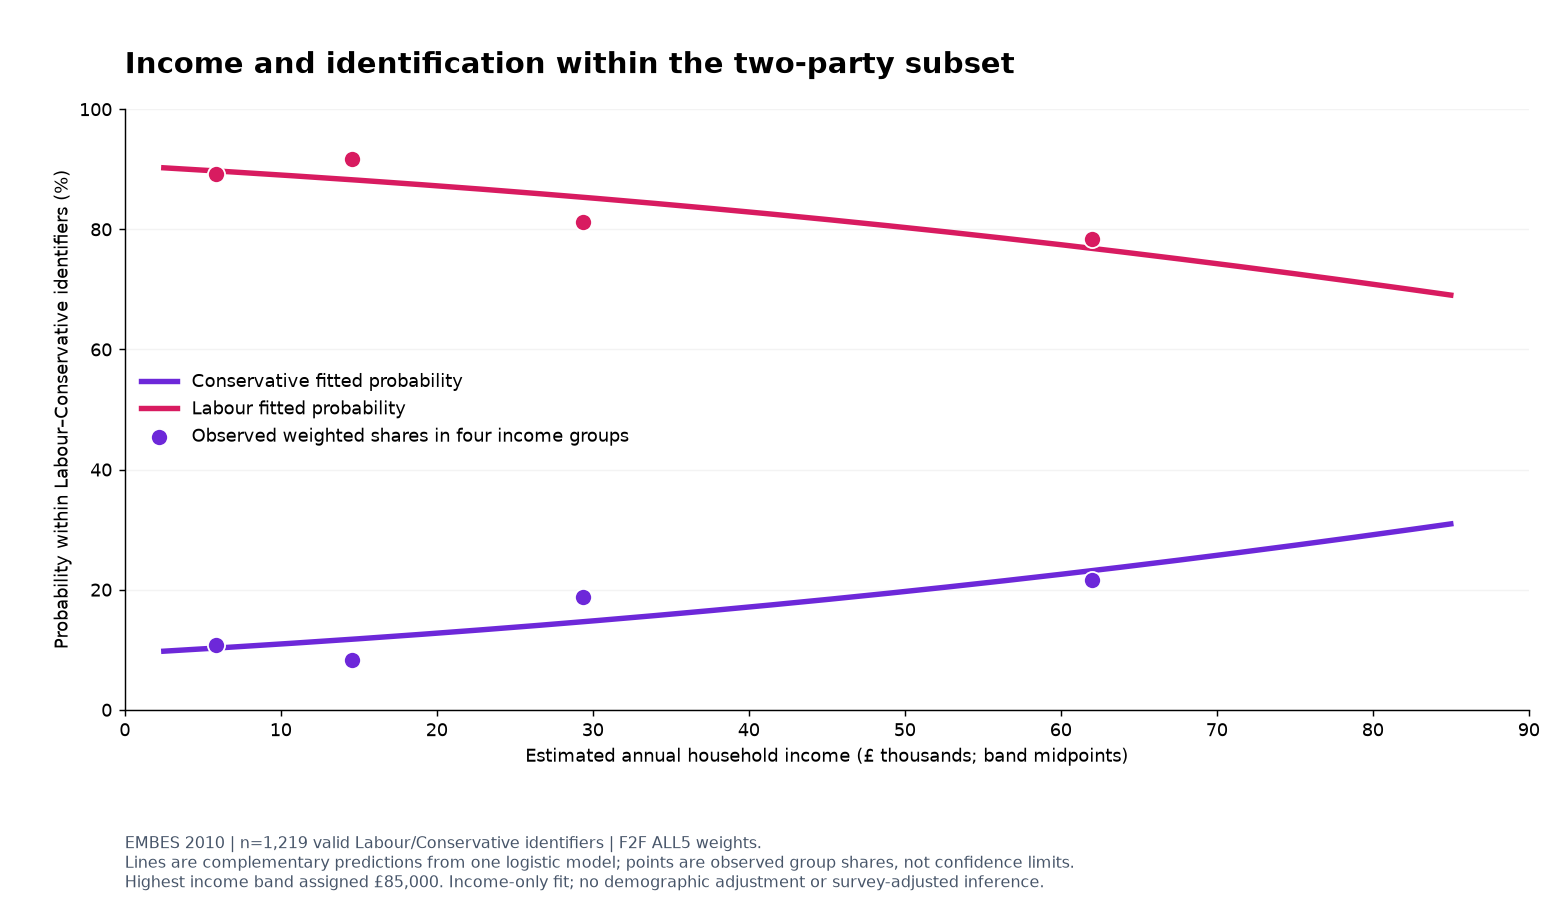

Descriptive model predictions among Labour/Conservative identifiers:
£10,000: Conservative 11.0%; Labour 89.0%
£40,000: Conservative 17.1%; Labour 82.9%
£80,000: Conservative 29.1%; Labour 70.9%

Sensitivity to assumed highest-band midpoint (not additional tests):
Top midpoint £85,000: predicted Conservative share 11.0% at £10,000 and 17.1% at £40,000
Top midpoint £100,000: predicted Conservative share 11.2% at £10,000 and 16.7% at £40,000
Top midpoint £120,000: predicted Conservative share 11.5% at £10,000 and 16.2% at £40,000


In [ ]:
# Supporting model: Conservative versus Labour identification only.
# Survey-weighted logistic fit; no claim of survey-adjusted significance.
from scipy.optimize import minimize
from scipy.special import expit

reg_data = complete.loc[complete['Party'].isin(['Labour', 'Conservative'])].copy()
midpoints = dict(zip(range(1, 15), [2500, 7500, 12500, 17500, 22500,
    27500, 32500, 37500, 42500, 47500, 55000, 65000, 75000, 85000]))
# £85,000 for the open highest band is an assumption, checked below.
reg_data['Income_midpoint'] = reg_data['Income'].map(midpoints)

def fit_party_logit(top_midpoint=85000):
    income = reg_data['Income_midpoint'].copy()
    income.loc[reg_data['Income'] == 14] = top_midpoint
    x = income.to_numpy() / 10000  # Income units: £10,000.
    X = np.column_stack([np.ones(len(x)), x])
    y = reg_data['Party'].eq('Conservative').to_numpy(dtype=float)
    w = reg_data['Weight'].to_numpy(dtype=float)
    w = w / w.mean()

    def loss(beta):
        score = X @ beta
        return np.sum(w * (np.logaddexp(0, score) - y * score))

    def gradient(beta):
        return X.T @ (w * (expit(X @ beta) - y))

    fit = minimize(loss, [0., 0.], jac=gradient, method='BFGS')
    assert fit.success, fit.message
    return fit.x

beta = fit_party_logit()
grid = np.linspace(2500, 85000, 200)
probability = expit(beta[0] + beta[1] * grid / 10000)

# Compare the fitted curve with actual weighted shares in four income groups.
reg_data['Group'] = pd.cut(reg_data['Income'], [0, 2, 4, 8, 14])
observed_x, observed_y = [], []
for _, group in reg_data.groupby('Group', observed=True):
    observed_x.append(np.average(group['Income_midpoint'], weights=group['Weight']))
    observed_y.append(np.average(group['Party'].eq('Conservative'), weights=group['Weight']))

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(grid / 1000, probability * 100, color='#6D28D9', lw=3,
        label='Conservative fitted probability')
ax.plot(grid / 1000, (1 - probability) * 100, color='#D81B60', lw=3,
        label='Labour fitted probability')
ax.scatter(np.array(observed_x) / 1000, np.array(observed_y) * 100,
           color='#6D28D9', edgecolor='white', s=90, zorder=3,
           label='Observed weighted shares in four income groups')
ax.scatter(np.array(observed_x) / 1000, (1 - np.array(observed_y)) * 100,
           color='#D81B60', edgecolor='white', s=90, zorder=3)
ax.set(xlim=(0, 90), ylim=(0, 100),
       xlabel='Estimated annual household income (£ thousands; band midpoints)',
       ylabel='Probability within Labour–Conservative identifiers (%)')
ax.set_title('Income and identification within the two-party subset',
             loc='left', fontsize=16, fontweight='bold', pad=20)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=.15)
ax.legend(loc='center left', frameon=False, fontsize=10)
fig.text(.08, .025,
         f'EMBES 2010 | n={len(reg_data):,} valid Labour/Conservative identifiers | F2F ALL5 weights.\n'
         'Lines are complementary predictions from one logistic model; points are observed group shares, not confidence limits.\n'
         'Highest income band assigned £85,000. Income-only fit; no demographic adjustment or survey-adjusted inference.',
         fontsize=9, color='#475569')
fig.subplots_adjust(left=.08, right=.98, top=.88, bottom=.22)
plt.show()

print('Descriptive model predictions among Labour/Conservative identifiers:')
for income in [10000, 40000, 80000]:
    p = expit(beta[0] + beta[1] * income / 10000)
    print(f'£{income:,}: Conservative {p:.1%}; Labour {1-p:.1%}')

# Check how assumptions for the open-ended band affect the fitted relationship.
print('\nSensitivity to assumed highest-band midpoint (not additional tests):')
for top in [85000, 100000, 120000]:
    b = fit_party_logit(top)
    p10, p40 = expit(b[0] + b[1] * np.array([1, 4]))
    print(f'Top midpoint £{top:,}: predicted Conservative share '
          f'{p10:.1%} at £10,000 and {p40:.1%} at £40,000')
